# Trump Analyysi

### Tavoite  
Tutkitaan uutislähteiden sanastoja Trumpia kohtaan. Tutkimme oikeistolaisia ja
vasemmistolaisia uutislähteitä ja vertaamme niitä keskustalaisiin uutislähteisiin.
Tavoitteena on selvittää, missä määrin eri poliittisen asennoitumiseen listatut
uutislähteet liittävät Trumpiin negatiivisia ja positiivisia sanoja.

### Datasetti

- Datasetti koostuu uutisartikkeleiden otsikoista lukuisista eri uutislähteistä. 
- Kaikki artikkelit ovat julkaustu 1.1.2026 - 31.3.2026 välisenä aikana.
- Artikkelien kaikissa otsikoissa on sana "Trump".
- Mediat: ['bbc.com', 'breitbart.com', 'democracynow.org', 'forbes.com', 'foxnews.com', 'reuters.com', 'theatlantic.com', 'theguardian.com', 'thepostmillennial.com']

In [1]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import opinion_lexicon
import re
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import stats

In [2]:
DATA_FILE = 'data.csv'
MEDIA_BIAS_CHART = 'media_bias_chart.png'

In [3]:
df = pd.read_csv(DATA_FILE, encoding='utf-8')

In [4]:
len(df)

4579

In [5]:
df.head()

,media_url,date,title,url
0,foxnews.com,3/6/2026,Trump says US could ‘take’ Iran’s uranium afte...,https://www.foxnews.com/politics/trump-says-us...
1,foxnews.com,3/24/2026,Trump says Iran’s navy ‘obliterated’ as US enf...,https://www.foxnews.com/politics/trump-says-ir...
2,breitbart.com,3/31/2026,Trump Addresses Concerns Over Rise in Gas Pric...,https://www.breitbart.com/politics/2026/03/31/...
3,foxnews.com,3/31/2026,Ex-Vikings captain is 'sick' Minnesota is in l...,https://www.foxnews.com/sports/ex-vikings-capt...
4,theguardian.com,3/31/2026,Morning Mail: draft Labor national platform re...,https://www.theguardian.com/australia-news/202...


Tarkistetaan vielä, että jokaisessa otsikossa on sana "Trump".

In [6]:
df = df[df['title'].str.contains('Trump', case=False, na=False)]

In [7]:
len(df)

4579

Kaikki uutislähteet

In [8]:
print(sorted(df['media_url'].unique()))

['bbc.com', 'breitbart.com', 'democracynow.org', 'forbes.com', 'foxnews.com', 'reuters.com', 'theatlantic.com', 'theguardian.com', 'thepostmillennial.com']


Tehdään "bias mapping" AllSides Media Bias kaavion mukaan.
https://www.allsides.com/media-bias/media-bias-chart

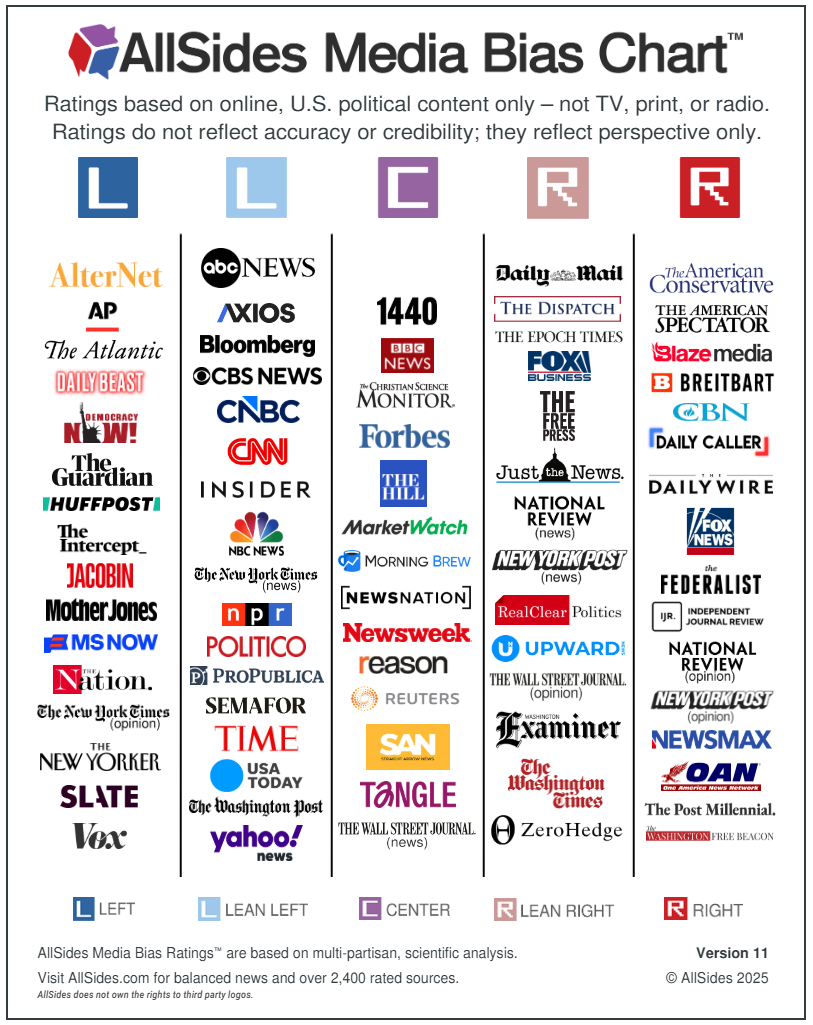

In [9]:
display(Image(filename=MEDIA_BIAS_CHART))

In [10]:
bias_mapping = {
    'foxnews.com': 'R',
    'breitbart.com': 'R',
    'thepostmillennial.com': 'R',
    
    'reuters.com': 'C',
    'bbc.com': 'C',
    'forbes.com': 'C',
    
    'democracynow.org': 'L',
    'theatlantic.com': 'L',
    'theguardian.com': 'L',
}

L (Left): Vasemmisto  
C (Center): Keskusta   
R (Right): Oikeisto  

In [11]:
df['bias'] = df['media_url'].map(bias_mapping)

In [12]:
df.head()

,media_url,date,title,url,bias
0,foxnews.com,3/6/2026,Trump says US could ‘take’ Iran’s uranium afte...,https://www.foxnews.com/politics/trump-says-us...,R
1,foxnews.com,3/24/2026,Trump says Iran’s navy ‘obliterated’ as US enf...,https://www.foxnews.com/politics/trump-says-ir...,R
2,breitbart.com,3/31/2026,Trump Addresses Concerns Over Rise in Gas Pric...,https://www.breitbart.com/politics/2026/03/31/...,R
3,foxnews.com,3/31/2026,Ex-Vikings captain is 'sick' Minnesota is in l...,https://www.foxnews.com/sports/ex-vikings-capt...,R
4,theguardian.com,3/31/2026,Morning Mail: draft Labor national platform re...,https://www.theguardian.com/australia-news/202...,L


In [13]:
unmapped = df[df['bias'].isna()]

if not unmapped.empty:
    print("HUOMIO! Seuraavia lähteitä ei löytynyt sanakirjasta ja ne jäivät ilman ryhmää:")
    print(unmapped['media_url'].unique())
else:
    print("Kaikki artikkelit on ryhmitelty ryhmiin R, C tai L.")

Kaikki artikkelit on ryhmitelty ryhmiin R, C tai L.


In [14]:
bias_counts = df['bias'].value_counts()
print("Artikkelien lukumäärä ryhmittäin:")
print(bias_counts)

Artikkelien lukumäärä ryhmittäin:
bias
R    2172
C    1389
L    1018
Name: count, dtype: int64


Pienennetään suurempien ryhmien (R ja C) kokoa satunnaisesti, jotta ne vastaavat pienintä ryhmää.

In [15]:
min_koko = df['bias'].value_counts().min()
df= df.groupby('bias').sample(n=min_koko, random_state=42)
print("Artikkelien lukumäärä ryhmittäin:")
print(df['bias'].value_counts())

Artikkelien lukumäärä ryhmittäin:
bias
C    1018
L    1018
R    1018
Name: count, dtype: int64


Text(0.5, 1.0, 'Artikkelien jakauma poliittisen suuntauksen mukaan (R, C, L)')

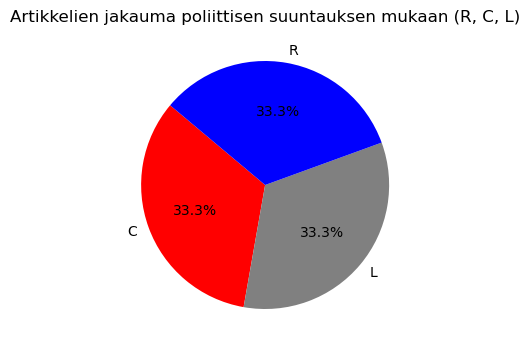

In [16]:
plt.figure(figsize=(4,6))

colors = {'R': "red", 'C': "gray", 'L': "blue"}
pie_colors = [colors.get(idx, '#cccccc') for idx in bias_counts.index]
bias_counts = df['bias'].value_counts()

plt.pie(bias_counts, 
        labels=bias_counts.index, 
        autopct='%1.1f%%',
        colors=pie_colors, 
        startangle=140)

plt.title('Artikkelien jakauma poliittisen suuntauksen mukaan (R, C, L)')

### Yksinkertainen sentimentti-analyysi sanalistoja käyttäen

In [17]:
nltk.download('opinion_lexicon')

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /home/hans/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


True

In [18]:
positiiviset_sanat = set(opinion_lexicon.positive())
negatiiviset_sanat = set(opinion_lexicon.negative())

print(f"Positiivisia sanoja yhteensä: {len(positiiviset_sanat)}")
print(f"Negatiivisia sanoja yhteensä: {len(negatiiviset_sanat)}")

print("\nEsimerkkejä positiivisista:", list(positiiviset_sanat)[:5])
print("Esimerkkejä negatiivisista:", list(negatiiviset_sanat)[:5])

Positiivisia sanoja yhteensä: 2006
Negatiivisia sanoja yhteensä: 4783

Esimerkkejä positiivisista: ['masterpieces', 'unparalleled', 'streamlined', 'orderly', 'tingle']
Esimerkkejä negatiivisista: ['capsize', 'draconic', 'eyesore', 'insufferably', 'fallaciously']


In [19]:
def laske_sanat(teksti):
    # Muutetaan pieniksi kirjaimiksi ja poimitaan vain sanat
    sanat = re.findall(r'\b[a-z]+\b', teksti.lower())
    
    pos_maara = sum(1 for sana in sanat if sana in positiiviset_sanat)
    neg_maara = sum(1 for sana in sanat if sana in negatiiviset_sanat)
    
    return pd.Series([pos_maara, neg_maara])

In [20]:
# Luodaan kaksi uutta saraketta
df[['pos_count', 'neg_count']] = df['title'].apply(laske_sanat)

# Lasketaan ryhmäkohtaiset KESKIARVOT (per otsikko)
tulokset = df.groupby('bias')[['pos_count', 'neg_count']].mean()

print("Keskimääräinen tunnesanojen määrä per otsikko ryhmittäin:")
print(tulokset)

Keskimääräinen tunnesanojen määrä per otsikko ryhmittäin:
      pos_count  neg_count
bias                      
C      1.265226   0.419450
L      1.339882   0.716110
R      1.442043   0.643418


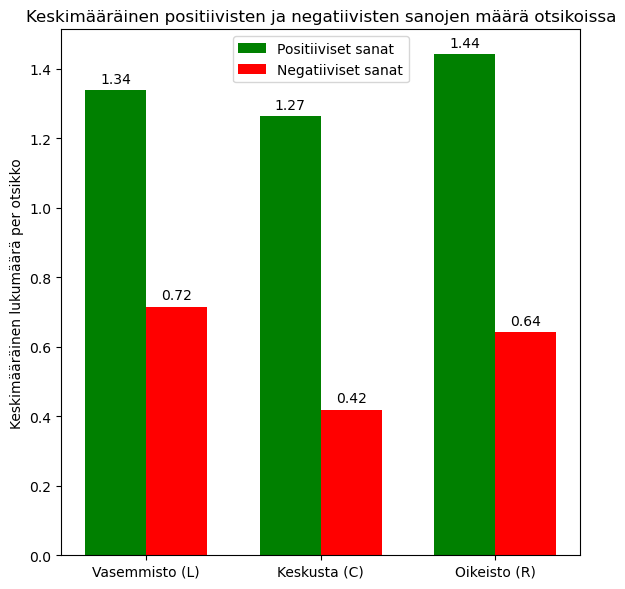

In [21]:

jarjestys = ['L', 'C', 'R']
tulokset_plot = tulokset.reindex(jarjestys)

x = np.arange(len(tulokset_plot.index))
pylvaan_leveys = 0.35

fig, ax = plt.subplots(figsize=(6, 6))

# Positiiviset pylväät vähän vasemmalle, negatiiviset vähän oikealle keskikohdasta
rects1 = ax.bar(x - pylvaan_leveys/2, tulokset_plot['pos_count'], pylvaan_leveys, 
                label='Positiiviset sanat', color='green')
rects2 = ax.bar(x + pylvaan_leveys/2, tulokset_plot['neg_count'], pylvaan_leveys, 
                label='Negatiiviset sanat', color='red') 

ax.set_ylabel('Keskimääräinen lukumäärä per otsikko')
ax.set_title('Keskimääräinen positiivisten ja negatiivisten sanojen määrä otsikoissa')
ax.set_xticks(x)
ax.set_xticklabels(['Vasemmisto (L)', 'Keskusta (C)', 'Oikeisto (R)'])
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()

Keskustalainen media (C) käyttää selvästi vähiten sekä positiivisia (1.27) että negatiivisia (0.42) tunnesanoja. Tämä on loogista ja tukee oletusta, että keskustalaiset lähteet pyrkivät otsikoinnissaan asiapitoisempaan ja vähemmän latautuneeseen kieleen.

Sekä vasemmisto (L) että oikeisto (R) käyttävät otsikoissaan enemmän tunnesanoja kuin keskusta, mikä viittaa otsikoiden voimakkaampaan asenteellisuuteen.

Oikeistolaisissa otsikoissa vilisee eniten positiivisia sanoja (1.44), kun taas vasemmistolaisissa otsikoissa on selvästi eniten negatiivisia sanoja (0.72).

Kaikissa ryhmissä näyttää olevan enemmän positiivisia kuin negatiivisia sanoja. Yksinkertaisen sanalaskurin heikkous on tietenkin se, että se ei ymmärrä asiayhteyttä. Emme tiedä, liitetäänkö positiivinen sana Trumpiin, vai johonkin muuhun.
Emme myöskään tiedä kumoaako edeltävä sana sen merkityksen (esim. "not successful" lasketaan tässä edelleen positiiviseksi).

Tarkistetaan vielä, että tulokset ovat tilastollisesti merkittäviä.

In [22]:
# Erotellaan ryhmien data omiksi muuttujikseen
pos_L = df[df['bias'] == 'L']['pos_count']
pos_C = df[df['bias'] == 'C']['pos_count']
pos_R = df[df['bias'] == 'R']['pos_count']

neg_L = df[df['bias'] == 'L']['neg_count']
neg_C = df[df['bias'] == 'C']['neg_count']
neg_R = df[df['bias'] == 'R']['neg_count']

# Suoritetaan Kruskal-Wallis -testi
stat_pos, p_pos = stats.kruskal(pos_L, pos_C, pos_R)
stat_neg, p_neg = stats.kruskal(neg_L, neg_C, neg_R)

print(f"Positiivisten sanojen p-arvo: {p_pos}")
print(f"Negatiivisten sanojen p-arvo: {p_neg}")


Positiivisten sanojen p-arvo: 2.151397627666096e-09
Negatiivisten sanojen p-arvo: 1.2111061103820443e-16


Molempien testien p-arvot ovat äärettömän pieniä ja reilusti alle tavallisen tieteellisen 0,05 rajan. Nollahypoteesi voidaan siis hylätä hyvillä mielin ja todeta, että erot näiden kolmen ryhmän sanavalinnoissa eivät johdu satunnaisvaihtelusta. Poliittinen puoleellisuus vaikuttaa *yllättäen* siihen, millaisia sanoja otsikoihin valikoituu.

### VADER

Vader toimii asteikolla (-1, 1), missä -1 on todella negatiivinen, 0 neutraali ja 1 todella positiivinen.

SE on alunperin suunniteltu sosiaalisen mediaan sentimentti analyysiin, mutta se soveltuu myös hyvin tällaiseen työhön.

Lisää tietoa VADER:ista:
https://github.com/cjhutto/vadersentiment

In [23]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/hans/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [24]:
analyzer = SentimentIntensityAnalyzer()

def hae_sentimentti(teksti):
    if pd.isna(teksti): return 0
    return analyzer.polarity_scores(str(teksti))['compound']

df['vader'] = df['title'].apply(hae_sentimentti)

df['bias'] = df['media_url'].map(bias_mapping)

kategoria_jarjestys = ['L', 'C', 'R']
df['bias'] = pd.Categorical(df['bias'], categories=kategoria_jarjestys, ordered=True)

bias_tulokset = df.groupby('bias', observed=False)['vader'].agg(['mean', 'count'])

print("Sentimentti ryhmittäin")
print(bias_tulokset)

Sentimentti ryhmittäin
          mean  count
bias                 
L    -0.179469   1018
C    -0.078301   1018
R    -0.068417   1018


In [25]:
lahde_analyysi = df.groupby('media_url')['vader'].agg(['mean', 'count']).sort_values(by='mean')
print("Sentimentti uutislähteittäin")
print(lahde_analyysi)

Sentimentti uutislähteittäin
                           mean  count
media_url                             
democracynow.org      -0.299275     48
theguardian.com       -0.174678    880
theatlantic.com       -0.162418     90
bbc.com               -0.128245    264
thepostmillennial.com -0.122615     41
forbes.com            -0.108088     67
foxnews.com           -0.075293    567
reuters.com           -0.056204    687
breitbart.com         -0.053488    410


Tulokset paljastavat, että kaikkien ryhmien (L, C, R) ja uutislähteiden keskimääräinen sävy Trumpiin liittyvissä otsikoissa on negatiivinen. Yksikään uutislähde ei kirjoita keskimäärin Trumpista puhtaasti positiiviseen sävyyn.

Miksi? Maailmantilanne, Trumpin luonne, Iran sota.. jotain muita syitä?

Vasemmisto (L: -0.179) erottuu selvästi joukosta negatiivisimpana. Kun katsotaan lähdekohtaisia tuloksia, vasemmistolaiset lähteet pitävät kärkipaikkoja negatiivisuudessa: Democracy Now on ihan omassa luokassaan (-0.299), ja perässä tulevat The Guardian ja The Atlantic.

Keskusta (C: -0.078) ja Oikeisto (R: -0.068) ovat todella lähellä toisiaan ja selvästi lähempänä neutraalia (0.0) kuin vasemmisto. AllSides:in mukaan keskustalaiseksi Breitbart (-0.053) ja oikeistolaiseksi luokiteltu Reuters (-0.056) ovat sävyltään käytännössä tasoissa!

VADER paljstaa, että sanalista metodissa positiiviset sanat eivät oikeasti tehneet lauseista positiivisia. Oikeistonkin otsikot jäivät VADERin tarkastelussa negatiivisiksi. Tämä johtuu todennäköisesti siitä, että VADER ymmärtää kieltoja (esim. "no win" ei ole enää positiivinen asia, vaikka siinä on sana "win") tai ehkä myös siitä, että oikeistomedia uutisoi negatiivisista asioista käyttäen tietynlaista sanastoa.

##### VADER aikajana

Piirretään aikajana, joka näyttää VADER:in keskiarvosentimentin datan kattaman ajan välillä 1.1.2026 - 31.3.2026

In [26]:
print(df.columns)

Index(['media_url', 'date', 'title', 'url', 'bias', 'pos_count', 'neg_count',
       'vader'],
      dtype='object')


/tmp/ipykernel_805254/3345779672.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paivittainen_sentimentti = df.groupby(['date', 'bias'])['vader'].mean().unstack()


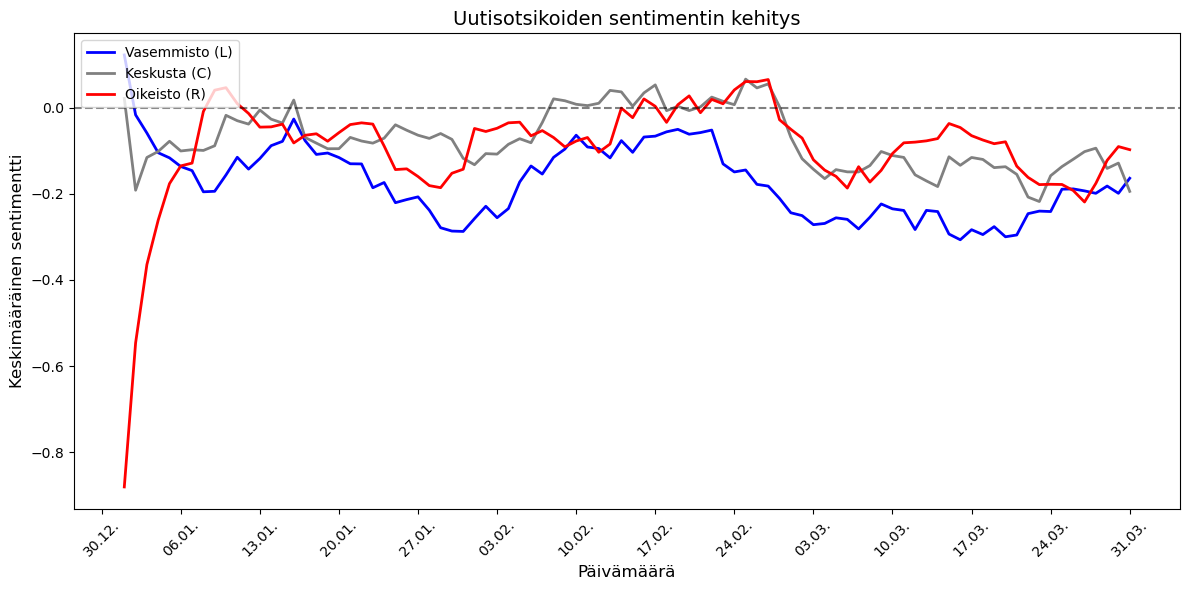

In [27]:
df['date'] = pd.to_datetime(df['date'])

# Lasketaan päivittäinen sentimentin keskiarvo kullekin bias-ryhmälle
paivittainen_sentimentti = df.groupby(['date', 'bias'])['vader'].mean().unstack()

# Otetaan 7 päivän liukuva keskiarvo
liukuva_keskiarvo = paivittainen_sentimentti.rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(liukuva_keskiarvo.index, liukuva_keskiarvo['L'], label='Vasemmisto (L)', color='blue', linewidth=2)
ax.plot(liukuva_keskiarvo.index, liukuva_keskiarvo['C'], label='Keskusta (C)', color='gray', linewidth=2)
ax.plot(liukuva_keskiarvo.index, liukuva_keskiarvo['R'], label='Oikeisto (R)', color='red', linewidth=2)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)

ax.set_title('Uutisotsikoiden sentimentin kehitys', fontsize=14)
ax.set_ylabel('Keskimääräinen sentimentti', fontsize=12)
ax.set_xlabel('Päivämäärä', fontsize=12)
ax.legend(loc='upper left')

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

**Miksi oikestomediat ovat niin negatiivisia alussa?**

Johtuuko se pienestä otoskoosta?

Aivan ensimmäisen päivän (1.1.) datapiste ei ole 7 päivän keskiarvo, vaan vain kyseisen yhden päivän keskiarvo. JOten ensimmäinen aito 7 päivän keskiarvo saavutetaan vasta tammikuun 7. päivän kohdalla. Tarkistetaan ensimmäisten päivien otoskoot.

In [28]:
df['date'] = pd.to_datetime(df['date'])

# 1. Suodatetaan data: Vain oikeisto ja tammikuun 6 ensimmäistä päivää
alku_df = df[(df['bias'] == 'R') & 
             (df['date'] >= '2026-01-01') & 
             (df['date'] <= '2026-01-06')]

# Tarkistetaan otoskoko: Kuinka monta artikkelia per päivä?
otoskoot = alku_df['date'].dt.date.value_counts().sort_index()
print("Artikkelieen määrä (oikeisto)")
print(otoskoot)

Artikkelieen määrä (oikeisto)
date
2026-01-01     1
2026-01-02     6
2026-01-03     9
2026-01-04     5
2026-01-05    14
2026-01-06    23
Name: count, dtype: int64


In [73]:
# Haetaan tuo uudenvuodenpäivän ainoa oikesto artikkeli
a_1_1_r = df[(df['date'] == '2026-01-01') & (df['bias'] == 'R')]

# Tulostetaan sen lähde, otsikko ja VADER-arvo
for index, row in a_1_1_r.iterrows():
    print(f"Lähde: {row['media_url']}")
    print(f"Otsikko: {row['title']}")
    print(f"VADER-arvo: {row['vader']}")
    print(f"Linkki: {row['url']}")

Lähde: breitbart.com
Otsikko: VIDEO: President Trump Vows to Fix Minnesota's Fraud Problem — 'It Was a Giant Scam'
VADER-arvo: -0.8807
Linkki: https://www.breitbart.com/politics/2026/01/01/video-president-trump-vows-to-fix-minnesotas-fraud-problem-it-was-a-giant-scam/


Mysteeri ratkaistu. Tässä kuitenkin huomataan VADER:in heikkoudet. SE ei ole tarpeeksi "älykäs" tajuamaan otsikosta, että Trumpia esiteetän hyvin positiivisessa, jopa sankarillisessa valossa tässä. Koska VADER on sanastopohjainen, eikä kontekstuaalinen, se ei kykene ymmärtämään lauseen syntaktisia rooleja tai poliittista kehystystä. Se kiinnittää vain huomiota otsikon negatiivisiin sanoihin, kuten "fraud", "scam" ja "problem", ja siitä syystä arvo on niin pieni (melkein -1).

Olisiko aika järeämmille aseille?

### Topic Modeling

Koska VADER osoittautui puutteelliseksi ymmärtämään kontekstia (kuten "giant scam" -otsikon kohdalla), siirrymme järeämpiin menetelmiin. Aihemallinnuksen avulla pyrimme selvittämään, **mitkä teemat** korostuvat vasemmiston, keskustan ja oikeiston Trump-uutisoinnissa.

Käytämme **LDA (Latent Dirichlet Allocation)** -algoritmia. Ensin siivoamme otsikoista pois yleiset "hukkasanat" (stopwords) sekä sanat, jotka esiintyvät lähes jokaisessa otsikossa (kuten "Trump", "President", "Video"), jotta ne eivät peitä varsinaisia uutisaiheita alleen.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF 
import nltk
from nltk.corpus import stopwords
import seaborn as sns

In [66]:
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /home/hans/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Nämä sanat eivät tuo lisäarvoa teemoihin tässä aineistossa
custom_stops = [
    'trump', 'trumps', 'donald', 'president', 'administration', 
    'says', 'tells', 'threatens', 'new', 'news', 'video', 'watch', 
    'glance', 'white', 'house', 'white house'
]
stop_words.extend(custom_stops)

vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    max_df=0.15,           
    min_df=3,              
    ngram_range=(1, 2)     
)
X = vectorizer.fit_transform(df['title'])

n_topics = 5
nmf_model = NMF(n_components=n_topics, random_state=42)
nmf_model.fit(X)

def nayta_aiheet(malli, vektorisoija, top_n=8):
    sanat = vektorisoija.get_feature_names_out()
    aihe_sanakirja = {}
    for i, topic in enumerate(malli.components_):
        top_sanat = [sanat[j] for j in topic.argsort()[:-top_n - 1:-1]]
        aihe_sanakirja[f"Aihe {i}"] = ", ".join(top_sanat)
        print(f"Aihe {i}: {', '.join(top_sanat)}")
    return aihe_sanakirja

print("LÖYTYNYT AIHEET (NMF):")
aiheet = nayta_aiheet(nmf_model, vectorizer)

LÖYTYNYT AIHEET (NMF):
--------------------------------------------------
Aihe 0: us, venezuela, oil, military, deal, strikes, maduro, cuba
Aihe 1: war, iran war, war iran, end, end war, could, ukraine, soon
Aihe 2: greenland, nato, europe, tariffs, tariff, take, starmer, threat
Aihe 3: court, supreme, supreme court, tariffs, ruling, global, tariffs ruling, justices
Aihe 4: state, union, state union, address, union address, speech, democrats, congress


In [68]:
topic_results = nmf_model.transform(X)
df['dominant_topic'] = topic_results.argmax(axis=1)

aihe_jakauma = pd.crosstab(df['bias'], df['dominant_topic'], normalize='index') * 100
aihe_jakauma = aihe_jakauma.reindex(['L', 'C', 'R'])

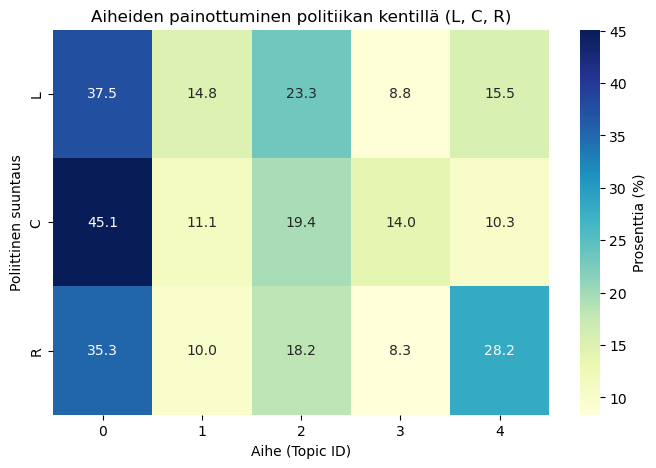

In [69]:
plt.figure(figsize=(8, 5))
sns.heatmap(aihe_jakauma, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Prosenttia (%)'})
plt.title('Aiheiden painottuminen politiikan kentillä (L, C, R)')
plt.ylabel('Poliittinen suuntaus')
plt.xlabel('Aihe (Topic ID)')
plt.show()

### Kielimallipohjainen analyysi?